
# Customer Churn & Spend Analytics — End-to-End Walkthrough of Gemini Enterprise Agent Platform (formerly Vertex AI)

This notebook uses **one small, easy-to-read dataset** to walk through every major item under the **Models** section of **Gemini Enterprise Agent Platform** (the current name for what many still call "Vertex AI"):

| # | Component | What we'll do with it |
|---|---|---|
| 1 | **Managed Dataset** | Register our CSV as an Agent Platform Tabular Dataset |
| 2 | **Feature Store** | Store & serve customer features from BigQuery via an online Feature Store |
| 3 | **Experiments, Runs & Metadata Store** | Log every training run's parameters and metrics, and inspect the underlying Metadata Store nodes directly |
| 4 | **Custom Training** | Train our own scikit-learn model as a `CustomJob` on managed infrastructure |
| 5 | **Hyperparameter Tuning (HPT)** | Let Agent Platform's built-in Vizier optimizer search for the best hyperparameters automatically |
| 6 | **AutoML** | Train a no-code AutoML Tabular model on the same data (with an important caveat — see Section 8) |

Every section ends with a **"🖥️ Check it in the console"** box telling you exactly where to click in the Google Cloud Console to see what just happened.

---

## Problem Statement

We are a retail company that wants to reduce **customer churn** and better understand **customer spend**. We have basic CRM data for 100 customers. We want to:

1. **Predict which customers are likely to churn** (binary classification) — so retention teams can act early.
2. **Predict how much a customer is likely to spend annually** (regression) — for revenue forecasting.
3. Do both of the above while learning how each Gemini Enterprise Agent Platform "Models" capability fits into a real ML workflow, and how they connect to each other (Dataset → Feature Store → Training → Experiments → Model Registry).

We are **not** trying to build a production-grade model here — the dataset is intentionally tiny (100 rows) so every step runs in seconds and is easy to reason about. The focus is the **platform mechanics**, not model accuracy.

---

## The Dataset

`customer_dataset.csv` — 100 synthetic customers, 10 columns:

| Column | Type | Description |
|---|---|---|
| `customer_id` | string | Unique customer identifier (e.g. `CUST001`) — used as the **entity ID** for Feature Store |
| `age` | int | Customer age |
| `income` | float | Annual income (₹/$) |
| `region` | categorical | North / South / East / West |
| `membership_tier` | categorical | Basic / Silver / Gold |
| `tenure_months` | int | Months since signup |
| `num_purchases` | int | Total number of purchases |
| `annual_spend` | float | Total annual spend — **regression target** |
| `satisfaction_score` | float | Self-reported satisfaction, 1–10 |
| `churned` | int (0/1) | Whether the customer churned — **classification target** |

The data has realistic correlations baked in (longer tenure and higher satisfaction → lower churn; higher income/purchases → higher spend), an intentionally imbalanced churn rate (~22%), and 4 planted outliers in spend/purchases, so it behaves like a real (if small) dataset rather than random noise.

> ⚠️ **Important note on scale:** AutoML Tabular on Gemini Enterprise Agent Platform generally expects **at least ~1,000 rows** to train reliably. With only 100 rows, **Custom Training and Hyperparameter Tuning are the right tools** for this dataset. We still show the AutoML workflow end-to-end (Section 9) so you understand the mechanics, but we flag where a real project would need more data.

**Source of the dataset:** [`customer_dataset.csv`](https://github.com/himanshurathi/gcp-training-labs-accordion/blob/master/day-4-vertex/customer_dataset.csv) in the `gcp-training-labs-accordion` repo (`day-4-vertex` folder). The notebook loads it directly from this GitHub source so it always matches the canonical training-lab copy; a local synthetic-generation fallback is included in case the URL is unreachable.

---

### A note on terminology

As of mid-2026, Google folded **Vertex AI** into the broader **Gemini Enterprise Agent Platform** — in the Google Cloud Console, the "Vertex AI" left-nav item is gone, and everything it used to cover (Datasets, Feature Store, Experiments, Training, Model Registry) now lives under **Agent Platform > Models**. This notebook uses "Agent Platform" throughout to match that current console navigation.

Two things did **not** change, so don't be surprised to still see "Vertex AI" in code and URLs:
- The **Python SDK package** is still `google-cloud-aiplatform`, imported as `from google.cloud import aiplatform` (this is what we use throughout this notebook).
- The **REST API endpoint** is still `aiplatform.googleapis.com`.

So: **"Agent Platform" is what you'll see in the console; `aiplatform` is what you'll see in code.** Both refer to the same underlying service.



## 1. Environment Setup

Run this once. After the install finishes, **restart the Colab runtime** (`Runtime > Restart session`) before continuing — this ensures the freshly installed package versions are picked up.

 **Note on `pandas`:** Colab's own tooling (`google-colab` package) is pinned to `pandas==2.2.2`. If you let `pip` install the latest `pandas` unconstrained, it may pull in `pandas 3.x`, which triggers a `pip` dependency-conflict warning and can quietly break Colab-native conveniences like `google.colab.data_table`. The install command below pins `pandas==2.2.2` explicitly to avoid this — if you still see the conflict warning afterward, it's safe to ignore as long as the version installed is `2.2.2`.


In [1]:
# 1.1 Install the required packages
# pandas is pinned to match the version google-colab itself depends on, to avoid the
# "google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.x" conflict warning.
# protobuf is pinned to a version new enough for tensorflow-metadata (pulled in by the
# Feature Store preview module in Section 5) to avoid a gencode/runtime VersionError.
!pip install --upgrade --quiet google-cloud-aiplatform google-cloud-storage google-cloud-bigquery cloudml-hypertune scikit-learn "pandas==2.2.2" "protobuf>=6.31.1"

In [2]:

# 1.2 Restart the runtime so the new package versions load cleanly
import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(True)


{'status': 'ok', 'restart': True}

In [2]:
# 1.2b Sanity check: confirm pandas landed on 2.2.x (post-restart). If this prints a 3.x
# version, re-run the install cell above -- something re-pulled an unpinned pandas.
import pandas as pd
print("pandas version:", pd.__version__)
assert pd.__version__.startswith("2."), (
    "pandas upgraded to a 3.x version, which conflicts with google-colab's pinned "
    "pandas==2.2.2. Re-run the install cell (Section 1.1) to re-pin it."
)

pandas version: 2.2.2



### 1.3 Authenticate (Colab)

This opens a browser popup for you to sign in with the Google account that has access to your Google Cloud project.


In [3]:

import sys

if 'google.colab' in sys.modules:
    from google.colab import auth
    auth.authenticate_user()
    print("Authenticated in Colab.")
else:
    print("Not running in Colab — make sure you've run `gcloud auth application-default login` locally instead.")


Authenticated in Colab.



### 1.4 Project configuration

Fill in your own `PROJECT_ID`. Everything else has sensible defaults.


In [4]:

PROJECT_ID = input("Enter your GCP Project ID: ").strip()
REGION = "us-central1"
BUCKET_NAME = f"{PROJECT_ID}-churn-demo-bucket"
BUCKET_URI = f"gs://{BUCKET_NAME}"
BQ_DATASET = "churn_demo"
BQ_TABLE = "customer_features"

EXPERIMENT_NAME = "customer-churn-experiments"

print(f"Project:  {PROJECT_ID}")
print(f"Region:   {REGION}")
print(f"Bucket:   {BUCKET_URI}")
print(f"BigQuery: {PROJECT_ID}.{BQ_DATASET}.{BQ_TABLE}")


Enter your GCP Project ID: cs-poc-ytkjb6nscjlihtluxkcmuoq
Project:  cs-poc-ytkjb6nscjlihtluxkcmuoq
Region:   us-central1
Bucket:   gs://cs-poc-ytkjb6nscjlihtluxkcmuoq-churn-demo-bucket
BigQuery: cs-poc-ytkjb6nscjlihtluxkcmuoq.churn_demo.customer_features


In [5]:

# 1.5 Enable the required Google Cloud APIs (one-time per project)
!gcloud config set project {PROJECT_ID}
!gcloud services enable aiplatform.googleapis.com storage.googleapis.com bigquery.googleapis.com --project {PROJECT_ID}


[environment: untagged] Read more to tag: g.co/cloud/project-env-tag.
Updated property [core/project].


To take a quick anonymous survey, run:
  $ gcloud survey

Operation "operations/acat.p2-226858601047-5677bf8d-915f-4521-87d4-af310f1168a6" finished successfully.


In [6]:

# 1.6 Initialize the Agent Platform SDK
# (package name is still `google-cloud-aiplatform` / `aiplatform` -- unchanged by the console rebrand)
from google.cloud import aiplatform

aiplatform.init(project=PROJECT_ID, location=REGION, staging_bucket=BUCKET_URI)
print("Agent Platform SDK initialized.")


Agent Platform SDK initialized.



> 🖥️ **Check it in the console:** Go to [IAM & Admin > IAM](https://console.cloud.google.com/iam-admin/iam) and confirm your account has the **Agent Platform User** role — this is the renamed `roles/aiplatform.user` IAM role, still shown as "Vertex AI User" in some IAM screens during the transition — or Owner/Editor. If any `gcloud services enable` command above failed, an admin needs to grant you `roles/serviceusage.serviceUsageAdmin`.



## 2. Load the Dataset

We load `customer_dataset.csv` directly from its canonical source on GitHub:

**https://github.com/himanshurathi/gcp-training-labs-accordion/blob/master/day-4-vertex/customer_dataset.csv**

If that URL is ever unreachable (network restrictions, repo moved, etc.), the fallback cell below regenerates an equivalent 100-row dataset locally with a fixed random seed, so the rest of the notebook still runs unchanged.


In [7]:

import numpy as np
import pandas as pd

GITHUB_RAW_URL = (
    "https://raw.githubusercontent.com/himanshurathi/"
    "gcp-training-labs-accordion/master/day-4-vertex/customer_dataset.csv"
)

try:
    df = pd.read_csv(GITHUB_RAW_URL)
    print(f"Loaded dataset from GitHub: {GITHUB_RAW_URL}")
except Exception as e:
    print(f"Could not load from GitHub ({e}). Falling back to local generation below.")
    df = None

if df is not None:
    df.to_csv('customer_dataset.csv', index=False)
    print(df.shape)
    if 'churned' in df.columns:
        print(f"Churn rate: {df['churned'].mean():.2%}")
df.head(10) if df is not None else None


Loaded dataset from GitHub: https://raw.githubusercontent.com/himanshurathi/gcp-training-labs-accordion/master/day-4-vertex/customer_dataset.csv
(100, 10)
Churn rate: 22.00%


,customer_id,age,income,region,membership_tier,tenure_months,num_purchases,annual_spend,satisfaction_score,churned
0,CUST001,56,21200.0,East,Gold,42,9,1067.910000,7.6,0
1,CUST002,69,30400.0,North,Silver,7,0,174.050000,4.8,0
2,CUST003,46,66500.0,East,Basic,16,8,1319.710000,6.5,1
3,CUST004,32,38700.0,West,Silver,90,66,11395.547905,10.0,0
4,CUST005,60,63600.0,North,Basic,60,13,1116.040000,8.9,0
5,CUST006,25,78500.0,South,Silver,2,5,1458.940000,5.2,1
6,CUST007,38,58800.0,West,Gold,1,5,1592.300000,7.0,0
7,CUST008,56,65700.0,East,Basic,48,10,1073.850000,6.9,1
8,CUST009,36,38900.0,East,Gold,12,5,1412.250000,3.5,1
9,CUST010,40,53000.0,East,Gold,69,14,2547.250000,7.5,0


In [8]:

# FALLBACK ONLY — run this cell if the GitHub load above failed.
# It regenerates a dataset with the same schema, size, and correlations, using a fixed seed.
if df is None:
    np.random.seed(42)

    n = 100
    regions = ['North', 'South', 'East', 'West']
    tiers = ['Basic', 'Silver', 'Gold']

    age = np.random.randint(18, 70, n)
    income = np.round(np.random.normal(55000, 18000, n).clip(15000, 150000), -2)
    tenure_months = np.random.randint(1, 96, n)
    region = np.random.choice(regions, n, p=[0.3, 0.25, 0.25, 0.2])
    tier = np.random.choice(tiers, n, p=[0.5, 0.3, 0.2])

    num_purchases = np.clip(
        (tenure_months / 6 + income / 20000 + np.random.normal(0, 3, n)).round().astype(int), 0, 60
    )

    tier_mult = np.array([1.0 if t == 'Basic' else 1.4 if t == 'Silver' else 2.0 for t in tier])
    annual_spend = np.round(
        (num_purchases * 45 + income * 0.01 + np.random.normal(0, 150, n)) * tier_mult, 2
    ).clip(50, None)

    satisfaction_score = np.clip(
        (5 + tenure_months / 24 + annual_spend / 3000 + np.random.normal(0, 1.2, n)).round(1), 1, 10
    )

    churn_logit = -0.04 * tenure_months - 0.5 * satisfaction_score - 0.04 * num_purchases + 4
    churn_prob = 1 / (1 + np.exp(-churn_logit))
    churned = (np.random.rand(n) < churn_prob).astype(int)

    outlier_idx = np.random.choice(n, 4, replace=False)
    annual_spend[outlier_idx] = annual_spend[outlier_idx] * np.random.uniform(4, 6, 4)
    num_purchases[outlier_idx] = (num_purchases[outlier_idx] * 3).clip(max=99)

    df = pd.DataFrame({
        'customer_id': [f'CUST{i+1:03d}' for i in range(n)],
        'age': age,
        'income': income,
        'region': region,
        'membership_tier': tier,
        'tenure_months': tenure_months,
        'num_purchases': num_purchases,
        'annual_spend': annual_spend,
        'satisfaction_score': satisfaction_score,
        'churned': churned,
    })
    df.to_csv('customer_dataset.csv', index=False)
    print("Generated fallback dataset locally.")

print(df.shape)
print(f"Churn rate: {df['churned'].mean():.2%}")
df.head(10)


(100, 10)
Churn rate: 22.00%


,customer_id,age,income,region,membership_tier,tenure_months,num_purchases,annual_spend,satisfaction_score,churned
0,CUST001,56,21200.0,East,Gold,42,9,1067.910000,7.6,0
1,CUST002,69,30400.0,North,Silver,7,0,174.050000,4.8,0
2,CUST003,46,66500.0,East,Basic,16,8,1319.710000,6.5,1
3,CUST004,32,38700.0,West,Silver,90,66,11395.547905,10.0,0
4,CUST005,60,63600.0,North,Basic,60,13,1116.040000,8.9,0
5,CUST006,25,78500.0,South,Silver,2,5,1458.940000,5.2,1
6,CUST007,38,58800.0,West,Gold,1,5,1592.300000,7.0,0
7,CUST008,56,65700.0,East,Basic,48,10,1073.850000,6.9,1
8,CUST009,36,38900.0,East,Gold,12,5,1412.250000,3.5,1
9,CUST010,40,53000.0,East,Gold,69,14,2547.250000,7.5,0


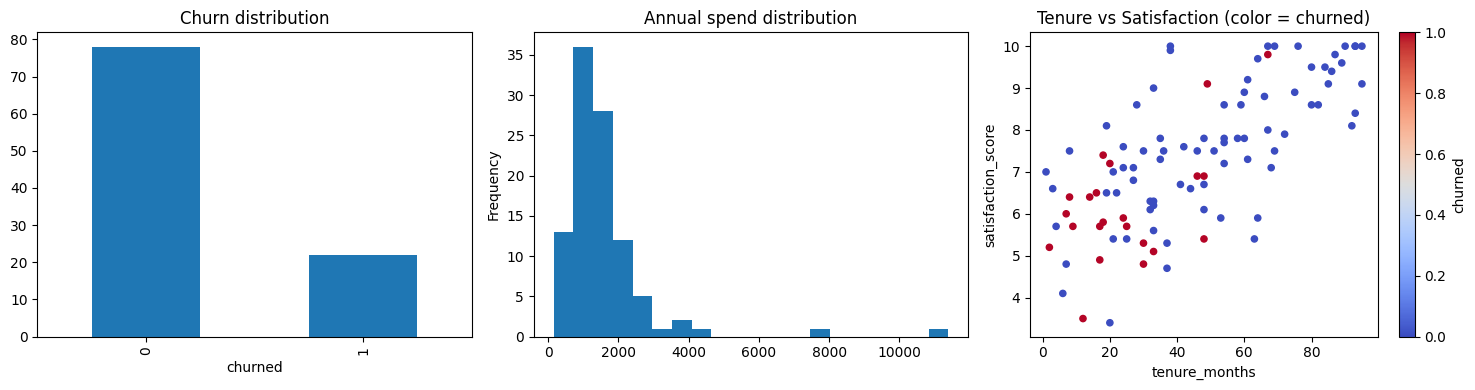

In [9]:

# Quick sanity-check visuals
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['churned'].value_counts().plot(kind='bar', ax=axes[0], title='Churn distribution')
df['annual_spend'].plot(kind='hist', bins=20, ax=axes[1], title='Annual spend distribution')
df.plot.scatter(x='tenure_months', y='satisfaction_score', c='churned', colormap='coolwarm', ax=axes[2], title='Tenure vs Satisfaction (color = churned)')
plt.tight_layout()
plt.show()



## 3. Upload Data to Cloud Storage & BigQuery

Gemini Enterprise Agent Platform's managed Dataset and Feature Store both prefer data sitting in **Cloud Storage** or **BigQuery**, so we push the CSV to both.


In [10]:

from google.cloud import storage

storage_client = storage.Client(project=PROJECT_ID)

# Create the bucket if it doesn't already exist
bucket = storage_client.lookup_bucket(BUCKET_NAME)
if bucket is None:
    bucket = storage_client.create_bucket(BUCKET_NAME, location=REGION)
    print(f"Created bucket {BUCKET_URI}")
else:
    print(f"Using existing bucket {BUCKET_URI}")

blob = bucket.blob("customer_dataset.csv")
blob.upload_from_filename("customer_dataset.csv")
GCS_CSV_URI = f"{BUCKET_URI}/customer_dataset.csv"
print(f"Uploaded to {GCS_CSV_URI}")


Created bucket gs://cs-poc-ytkjb6nscjlihtluxkcmuoq-churn-demo-bucket
Uploaded to gs://cs-poc-ytkjb6nscjlihtluxkcmuoq-churn-demo-bucket/customer_dataset.csv


In [11]:

from google.cloud import bigquery

bq_client = bigquery.Client(project=PROJECT_ID)

dataset_ref = bigquery.Dataset(f"{PROJECT_ID}.{BQ_DATASET}")
dataset_ref.location = REGION
bq_client.create_dataset(dataset_ref, exists_ok=True)

# Feature Store requires a feature_timestamp column for its BigQuery source
df_bq = df.copy()
df_bq['feature_timestamp'] = pd.Timestamp.utcnow()

table_id = f"{PROJECT_ID}.{BQ_DATASET}.{BQ_TABLE}"
job = bq_client.load_table_from_dataframe(
    df_bq, table_id,
    job_config=bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE"),
)
job.result()
print(f"Loaded {job.output_rows} rows into {table_id}")


Loaded 100 rows into cs-poc-ytkjb6nscjlihtluxkcmuoq.churn_demo.customer_features



> 🖥️ **Check it in the console:**
> - Cloud Storage: [console.cloud.google.com/storage/browser](https://console.cloud.google.com/storage/browser) → open your bucket → confirm `customer_dataset.csv` is there.
> - BigQuery: [console.cloud.google.com/bigquery](https://console.cloud.google.com/bigquery) → expand your project → `churn_demo` dataset → `customer_features` table → click **Preview** to see the rows.



## 4. Register an Agent Platform Managed Dataset

A **managed Dataset** is a Gemini Enterprise Agent Platform resource that wraps your data (here, the BigQuery table) so that AutoML and some Custom Training workflows can reference it directly, with built-in train/validation/test splitting.


In [12]:

tabular_dataset = aiplatform.TabularDataset.create(
    display_name="customer-churn-dataset",
    bq_source=f"bq://{PROJECT_ID}.{BQ_DATASET}.{BQ_TABLE}",
)

print(f"Dataset resource name: {tabular_dataset.resource_name}")


Dataset resource name: projects/226858601047/locations/us-central1/datasets/7637982097595957248



> 🖥️ **Check it in the console:** **Agent Platform > Models > Datasets** → you should see **customer-churn-dataset** listed, with its source pointing at your BigQuery table. Click into it to preview the schema Agent Platform inferred for each column.



## 5. Feature Store

Feature Store lets you **register features once** (from BigQuery) and **serve them consistently** for both training and low-latency online prediction — avoiding "training/serving skew." We'll:

1. Create an **Online Store** (Bigtable-backed).
2. Create a **Feature View** pointing at our BigQuery table (`customer_id` as the entity ID).
3. Sync it and fetch a live feature vector for one customer — exactly what a production prediction service would do.


In [13]:
from vertexai.resources.preview import feature_store

FEATURE_ONLINE_STORE_ID = "churn_demo_feature_store"
FEATURE_VIEW_ID = "customer_features_view"

# 5.1 Create a Bigtable-backed online store (small, autoscaling 1-1 node for this demo)
online_store = feature_store.FeatureOnlineStore.create_bigtable_store(
    FEATURE_ONLINE_STORE_ID,
)
print(f"Online store: {online_store.resource_name}")

INFO:vertexai.resources.preview.feature_store.feature_online_store:Creating FeatureOnlineStore
INFO:vertexai.resources.preview.feature_store.feature_online_store:Create FeatureOnlineStore backing LRO: projects/226858601047/locations/us-central1/featureOnlineStores/churn_demo_feature_store/operations/8887598919651950592
INFO:vertexai.resources.preview.feature_store.feature_online_store:FeatureOnlineStore created. Resource name: projects/226858601047/locations/us-central1/featureOnlineStores/churn_demo_feature_store
INFO:vertexai.resources.preview.feature_store.feature_online_store:To use this FeatureOnlineStore in another session:
INFO:vertexai.resources.preview.feature_store.feature_online_store:feature_online_store = aiplatform.FeatureOnlineStore('projects/226858601047/locations/us-central1/featureOnlineStores/churn_demo_feature_store')


Online store: projects/226858601047/locations/us-central1/featureOnlineStores/churn_demo_feature_store


In [ ]:

# 5.2 Create a Feature View sourced directly from our BigQuery table
feature_view = online_store.create_feature_view(
    name=FEATURE_VIEW_ID,
    source=feature_store.utils.FeatureViewBigQuerySource(
        uri=f"bq://{PROJECT_ID}.{BQ_DATASET}.{BQ_TABLE}",
        entity_id_columns=["customer_id"],
    ),
    sync_config="0 */6 * * *",  # re-sync every 6 hours; we'll also trigger a manual sync below
)
print(f"Feature view: {feature_view.resource_name}")


INFO:vertexai.resources.preview.feature_store.feature_online_store:Creating FeatureView
INFO:vertexai.resources.preview.feature_store.feature_online_store:Create FeatureView backing LRO: projects/616219418759/locations/us-central1/featureOnlineStores/churn_demo_feature_store/featureViews/customer_features_view/operations/3085572816901242880
INFO:vertexai.resources.preview.feature_store.feature_online_store:FeatureView created. Resource name: projects/616219418759/locations/us-central1/featureOnlineStores/churn_demo_feature_store/featureViews/customer_features_view
INFO:vertexai.resources.preview.feature_store.feature_online_store:To use this FeatureView in another session:
INFO:vertexai.resources.preview.feature_store.feature_online_store:feature_view = aiplatform.FeatureView('projects/616219418759/locations/us-central1/featureOnlineStores/churn_demo_feature_store/featureViews/customer_features_view')


Feature view: projects/616219418759/locations/us-central1/featureOnlineStores/churn_demo_feature_store/featureViews/customer_features_view


In [ ]:

# 5.3 Trigger an immediate sync (don't wait for the cron schedule) and poll until done
sync_op = feature_view.sync()
print("Sync started:", sync_op)

import time
while True:
    sync_status = feature_view.get_sync(sync_op.name if hasattr(sync_op, "name") else sync_op)
    status = getattr(sync_status, "final_status", None)
    if status is not None:
        print("Sync finished with status:", status)
        break
    time.sleep(10)


Sync started: <vertexai.resources.preview.feature_store.feature_view.FeatureView.FeatureViewSync object at 0x79fb35484770> 
resource name: projects/616219418759/locations/us-central1/featureOnlineStores/churn_demo_feature_store/featureViews/customer_features_view/featureViewSyncs/4417329456121643008


KeyboardInterrupt: 

In [ ]:

# 5.4 Read back a feature vector for one customer — this is what an online prediction
# service would call at request time.
response = feature_view.read(key=["CUST001"])
print("Live feature vector for CUST001:")
print(response.to_dict())



> 🖥️ **Check it in the console:** **Agent Platform > Models > Feature Store** → open **churn-demo-feature-store** → **customer-features-view** → the **Sync history** tab shows the sync job you just triggered, and the **Data** tab lets you browse served feature values.



## 6. Experiments, Runs & Metadata Store

This is the piece that ties every other section together, so it's worth understanding the three-level hierarchy before we write any code:

| Level | What it is | Analogy |
|---|---|---|
| **Experiment** | A named container for a group of related training attempts on the same problem | A lab notebook's title, e.g. "Customer Churn Experiments" |
| **Run** | One single attempt inside an Experiment — one set of hyperparameters, one training execution, with its own logged params and metrics | One dated page in that lab notebook |
| **Metadata Store** | The underlying, project-wide graph database that actually stores every Experiment, Run, parameter, metric, **Dataset**, **Model**, and **Execution** as connected nodes ("Artifacts", "Executions", "Contexts") — Experiments/Runs are really just a friendly view over this store | The archive room where every lab notebook, sample, and instrument log ends up, cross-referenced |

Concretely:
- Every project has **exactly one Metadata Store per region** (created automatically the first time you use Agent Platform in that region).
- An **Experiment** is a `Context` in that store.
- A **Run** is also a `Context`, nested under the Experiment, linked to `Execution` nodes (the actual training jobs) and `Artifact` nodes (the datasets consumed, models produced).
- This is *why* the Custom Training job in Section 7 and the Hyperparameter Tuning job in Section 8 can each be logged as a "Run" under the same Experiment — and why, later, you can trace a deployed Model in the Model Registry all the way back to the exact dataset version and hyperparameters that produced it.

We'll now create the Experiment, log our first Run (a quick local baseline), and then peek directly into the Metadata Store to see the raw `Context`/`Execution`/`Artifact` nodes behind the friendly Experiments UI.


In [14]:

aiplatform.init(project=PROJECT_ID, location=REGION, experiment=EXPERIMENT_NAME)
print(f"Experiment '{EXPERIMENT_NAME}' initialized.")
print("This Experiment lives inside the Metadata Store for:", f"{PROJECT_ID} / {REGION}")


Experiment 'customer-churn-experiments' initialized.
This Experiment lives inside the Metadata Store for: cs-poc-ytkjb6nscjlihtluxkcmuoq / us-central1


In [15]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

feature_cols = ['age', 'income', 'region', 'membership_tier', 'tenure_months',
                'num_purchases', 'satisfaction_score']
X = df[feature_cols]
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['region', 'membership_tier']),
], remainder='passthrough')

baseline_params = {"model": "logistic_regression", "C": 1.0, "max_iter": 200}

# Every `start_run` call below creates one Run (one Context node) nested under our Experiment.
with aiplatform.start_run(run="baseline-logistic-regression") as run:
    aiplatform.log_params(baseline_params)

    pipe = Pipeline([
        ('prep', preprocess),
        ('clf', LogisticRegression(C=baseline_params["C"], max_iter=baseline_params["max_iter"])),
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    metrics = {
        "accuracy": accuracy_score(y_test, preds),
        "f1_score": f1_score(y_test, preds),
    }
    aiplatform.log_metrics(metrics)

print("Baseline run logged:", metrics)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Baseline run logged: {'accuracy': 0.85, 'f1_score': 0.5714285714285714}


In [16]:

# Pull back every run logged so far as a DataFrame — this is the core "compare experiments" view.
# Each row here corresponds to one Run (Context) under our Experiment.
experiment_df = aiplatform.get_experiment_df(EXPERIMENT_NAME)
experiment_df


,experiment_name,run_name,run_type,state,param.max_iter,param.model,param.C,metric.f1_score,metric.accuracy
0,customer-churn-experiments,baseline-logistic-regression,system.ExperimentRun,COMPLETE,200.0,logistic_regression,1.0,0.571429,0.85



### Peeking at the raw Metadata Store

The cell below queries the Metadata Store directly for the underlying `Context` (Experiment/Run), `Execution` (the actual training process), and `Artifact` (datasets, models) nodes — the same objects the Experiments UI is built on top of.


In [17]:

from google.cloud.aiplatform import metadata

# List every Context in this project/region's Metadata Store whose schema marks it as
# an Experiment or ExperimentRun (there will be at least our Experiment + baseline Run).
contexts = aiplatform.Context.list(
    filter=f'schema_title="system.Experiment" OR schema_title="system.ExperimentRun"'
)
for ctx in contexts:
    print(f"[{ctx.schema_title}] {ctx.display_name}  ->  {ctx.resource_name}")


[system.ExperimentRun] baseline-logistic-regression  ->  projects/226858601047/locations/us-central1/metadataStores/default/contexts/customer-churn-experiments-baseline-logistic-regression
[system.Experiment] customer-churn-experiments  ->  projects/226858601047/locations/us-central1/metadataStores/default/contexts/customer-churn-experiments
[system.ExperimentRun] iris-run-1783499629  ->  projects/226858601047/locations/us-central1/metadataStores/default/contexts/training-experiment-1783499629-iris-run-1783499629
[system.Experiment] training-experiment-1783499629  ->  projects/226858601047/locations/us-central1/metadataStores/default/contexts/training-experiment-1783499629


In [18]:

# List Executions (actual runs of training code) and Artifacts (datasets/models produced)
# tracked anywhere in this Metadata Store.
executions = aiplatform.Execution.list()
artifacts = aiplatform.Artifact.list()

print(f"Executions tracked: {len(executions)}")
for e in executions[:10]:
    print(f"  - {e.display_name or e.resource_name}  (state: {e.state})")

print(f"\\nArtifacts tracked: {len(artifacts)}")
for a in artifacts[:10]:
    print(f"  - [{a.schema_title}] {a.display_name or a.resource_name}")


Executions tracked: 6
  - iris-training-pipeline-20260708122416  (state: 4)
  - train-model  (state: 4)
  - generate-data  (state: 5)
  - iris-training-pipeline-20260708120135  (state: 4)
  - train-model  (state: 4)
  - generate-data  (state: 3)
\nArtifacts tracked: 6
  - [google.VertexTensorboardRun] projects/226858601047/locations/us-central1/metadataStores/default/artifacts/customer-churn-experiments-baseline-logistic-regression-tb-run
  - [google.VertexDataset] vertex_dataset
  - [system.Model] output_model
  - [system.Dataset] output_dataset
  - [system.Model] output_model
  - [google.VertexTensorboardRun] projects/226858601047/locations/us-central1/metadataStores/default/artifacts/training-experiment-1783499629-iris-run-1783499629-tb-run



> 🖥️ **Check it in the console:**
> - **Agent Platform > Models > Experiments** → open **customer-churn-experiments** → the **baseline-logistic-regression** run shows its logged params (`C`, `max_iter`) and metrics (`accuracy`, `f1_score`) in a sortable table. Every subsequent Custom Training and HPT run below will show up in this same table.
> - **Agent Platform > Models > Metadata** → shows the raw **Contexts**, **Executions**, and **Artifacts** we just listed with code — click on any node to see its lineage graph (which dataset fed which execution, which produced which model).



## 7. Custom Training

Now we train a **Random Forest classifier** as a managed `CustomJob` — i.e., our own Python training code, packaged and run on Agent Platform's managed infrastructure (not our Colab kernel), with the trained model artifact written back to Cloud Storage and registered in the **Model Registry**.

### 7.1 Write the training script

This script will also be reused, unmodified, for hyperparameter tuning in Section 8 — it accepts `--n_estimators` and `--max_depth` as arguments and, when running inside an HPT trial, reports its metric back to Agent Platform's Vizier-based tuning service via `hypertune`.


In [19]:

%%writefile train.py
import argparse
import os

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
import joblib

try:
    import hypertune
    HAS_HYPERTUNE = True
except ImportError:
    HAS_HYPERTUNE = False


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--data-uri", type=str, required=True,
                         help="GCS path to customer_dataset.csv")
    parser.add_argument("--n-estimators", type=int, default=200)
    parser.add_argument("--max-depth", type=int, default=5)
    parser.add_argument("--model-dir", type=str,
                         default=os.environ.get("AIP_MODEL_DIR", "./model_output"))
    args = parser.parse_args()

    df = pd.read_csv(args.data_uri)

    feature_cols = ['age', 'income', 'region', 'membership_tier', 'tenure_months',
                     'num_purchases', 'satisfaction_score']
    X = df[feature_cols]
    y = df['churned']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    preprocess = ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['region', 'membership_tier']),
    ], remainder='passthrough')

    clf = RandomForestClassifier(
        n_estimators=args.n_estimators,
        max_depth=args.max_depth,
        random_state=42,
    )

    pipe = Pipeline([('prep', preprocess), ('clf', clf)])
    pipe.fit(X_train, y_train)

    preds = pipe.predict(X_test)
    accuracy = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    print(f"accuracy={accuracy:.4f} f1={f1:.4f}")

    # Report the metric back to Agent Platform's Hyperparameter Tuning service (no-op outside an HPT trial)
    if HAS_HYPERTUNE:
        hpt = hypertune.HyperTune()
        hpt.report_hyperparameter_tuning_metric(
            hyperparameter_metric_tag='accuracy',
            metric_value=accuracy,
            global_step=1,
        )

    # Save the trained model artifact
    os.makedirs(args.model_dir, exist_ok=True) if not args.model_dir.startswith("gs://") else None
    local_path = "model.joblib"
    joblib.dump(pipe, local_path)

    if args.model_dir.startswith("gs://"):
        from google.cloud import storage
        bucket_name, _, prefix = args.model_dir.replace("gs://", "").partition("/")
        client = storage.Client()
        blob = client.bucket(bucket_name).blob(f"{prefix.rstrip('/')}/model.joblib")
        blob.upload_from_filename(local_path)
        print(f"Model uploaded to {args.model_dir}/model.joblib")
    else:
        os.replace(local_path, os.path.join(args.model_dir, "model.joblib"))
        print(f"Model saved to {args.model_dir}/model.joblib")


if __name__ == "__main__":
    main()


Writing train.py



### 7.2 Submit the Custom Training job

We use a prebuilt scikit-learn training container so we don't have to build our own Docker image.


In [21]:
TRAIN_CONTAINER_URI = "us-docker.pkg.dev/vertex-ai/training/scikit-learn-cpu.0-23:latest"

custom_job = aiplatform.CustomJob.from_local_script(
    display_name="churn-rf-custom-training",
    script_path="train.py",
    container_uri=TRAIN_CONTAINER_URI,
    requirements=["cloudml-hypertune", "gcsfs"],
    args=[
        "--data-uri", GCS_CSV_URI,
        "--n-estimators", "200",
        "--max-depth", "5",
        "--model-dir", f"{BUCKET_URI}/models/custom-training",
    ],
    machine_type="e2-standard-4",  # or whichever machine type worked for your quota
    staging_bucket=BUCKET_URI,
)

custom_job.run(sync=True)
print("Custom training job state:", custom_job.state)

Custom training job state: 4


In [ ]:

# Log this run in the same Experiment for side-by-side comparison with the baseline
with aiplatform.start_run(run="custom-training-random-forest") as run:
    aiplatform.log_params({"model": "random_forest", "n_estimators": 200, "max_depth": 5})
    # In a real pipeline you'd parse the job logs or write metrics to a known GCS path;
    # here we re-read the printed accuracy from the job logs for demonstration.
    aiplatform.log_metrics({"trained_via": 1})  # placeholder marker; see console logs for the real accuracy/f1



> 🖥️ **Check it in the console:** **Agent Platform > Models > Training > Custom Jobs** → open **churn-rf-custom-training** → the **Logs** tab shows the `accuracy=... f1=...` line printed by our script. Then check [Cloud Storage](https://console.cloud.google.com/storage/browser) under `models/custom-training/` for the saved `model.joblib`.


# 7.3 Register the custom-trained model in the Model Registry

In [24]:

CUSTOM_SERVING_CONTAINER_URI = "us-docker.pkg.dev/vertex-ai/prediction/sklearn-cpu.1-0:latest"

custom_model = aiplatform.Model.upload(
    display_name="churn-custom-rf-model",
    artifact_uri=f"{BUCKET_URI}/models/custom-training",  # the folder containing model.joblib
    serving_container_image_uri=CUSTOM_SERVING_CONTAINER_URI,
)

print(f"Custom-trained model registered: {custom_model.resource_name}")

Custom-trained model registered: projects/226858601047/locations/us-central1/models/5254733744664739840



## 8. Hyperparameter Tuning (HPT)

Instead of guessing `n_estimators` and `max_depth`, we let Vertex AI Vizier run multiple trials and search for the combination that maximizes accuracy. We reuse the exact same `train.py` from Section 7 — it already reports its metric via `hypertune`, which is all Vizier needs.

Each trial gets its own model output subfolder (keyed by `CLOUD_ML_TRIAL_ID`, which Vertex AI sets automatically) so trials don't overwrite each other's saved models.

In [23]:
from google.cloud.aiplatform import hyperparameter_tuning as hpt

hpt_job_base = aiplatform.CustomJob.from_local_script(
    display_name="churn-rf-hpt-worker",
    script_path="train.py",
    container_uri=TRAIN_CONTAINER_URI,  # us-docker.pkg.dev/vertex-ai/training/scikit-learn-cpu.0-23:latest
    requirements=["cloudml-hypertune", "gcsfs"],
    args=[
        "--data-uri", GCS_CSV_URI,
        "--model-dir", f"{BUCKET_URI}/models/hpt-trials/trial_$CLOUD_ML_TRIAL_ID",
    ],
    machine_type="e2-standard-4",  # adjust if your project's quota needs a different family
    staging_bucket=BUCKET_URI,
)

hpt_job = aiplatform.HyperparameterTuningJob(
    display_name="churn-rf-hpt",
    custom_job=hpt_job_base,
    metric_spec={"accuracy": "maximize"},
    parameter_spec={
        "n-estimators": hpt.IntegerParameterSpec(min=50, max=300, scale="linear"),
        "max-depth": hpt.IntegerParameterSpec(min=2, max=12, scale="linear"),
    },
    max_trial_count=2,
    parallel_trial_count=1,  # sequential trials, to stay within a tight CPU quota
)

hpt_job.run(sync=True)
print("HPT job state:", hpt_job.state)

print("\nAll trials:")
for trial in hpt_job.trials:
    params = {p.parameter_id: p.value for p in trial.parameters}
    accuracy = trial.final_measurement.metrics[0].value
    print(f"  Trial {trial.id}: {params}  ->  accuracy={accuracy:.4f}")

KeyboardInterrupt: 

In [ ]:
# Identify the best trial by its reported accuracy
best_trial = max(hpt_job.trials, key=lambda t: t.final_measurement.metrics[0].value)
best_params = {p.parameter_id: p.value for p in best_trial.parameters}
best_accuracy = best_trial.final_measurement.metrics[0].value

print("Best trial ID:", best_trial.id)
print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)

# Log the best trial's params/metrics to our Experiment for side-by-side comparison
with aiplatform.start_run(run="hpt-best-trial") as run:
    aiplatform.log_params(best_params)
    aiplatform.log_metrics({"accuracy": best_accuracy})

# Register the best trial's model artifact in the Model Registry
CUSTOM_SERVING_CONTAINER_URI = "us-docker.pkg.dev/vertex-ai/prediction/sklearn-cpu.1-0:latest"

hpt_model = aiplatform.Model.upload(
    display_name="churn-hpt-best-model",
    artifact_uri=f"{BUCKET_URI}/models/hpt-trials/trial_{best_trial.id}",
    serving_container_image_uri=CUSTOM_SERVING_CONTAINER_URI,
)

print(f"\nBest HPT model registered: {hpt_model.resource_name}")


> 🖥️ **Check it in the console:** **Agent Platform > Models > Training > Hyperparameter Tuning Jobs** → open **churn-rf-hpt** → the **Trials** tab shows all 10 trials, their hyperparameter values, and the resulting accuracy — sortable, so you can see the best trial at a glance without writing any code.


In [ ]:
# 8.x Deploy the best HPT model to an online endpoint for real-time predictions
endpoint = hpt_model.deploy(
    deployed_model_display_name="churn-hpt-best-deployed",
    machine_type="e2-standard-4",  # match whichever family worked for your training quota
    min_replica_count=1,
    max_replica_count=1,
    sync=True,
)

print(f"Endpoint deployed: {endpoint.resource_name}")

In [ ]:
# Build one sample instance matching the feature columns train.py trained on
sample_instance = {
    "age": 35,
    "income": 60000.0,
    "region": "East",
    "membership_tier": "Silver",
    "tenure_months": 24,
    "num_purchases": 12,
    "satisfaction_score": 7.5,
}

prediction = endpoint.predict(instances=[sample_instance])
print("Prediction response:", prediction)

In [ ]:
sample_instance = [35, 60000.0, "East", "Silver", 24, 12, 7.5]
prediction = endpoint.predict(instances=[sample_instance])


## 9. AutoML Tabular

Finally, the no-code path: point AutoML at the managed Dataset from Section 4 and let it handle feature engineering, model search, and hyperparameter tuning automatically.

> ⚠️ **Row-count caveat, restated:** AutoML Tabular's training pipeline generally needs **~1,000+ rows** to reliably split into train/validation/test and search architectures. With our 100-row dataset, this job may fail validation or produce an unstable model. This section shows you the **exact mechanics** you'd use on a production-sized dataset. If you want to see it complete successfully as a learning exercise, uncomment the row-duplication line below to synthetically pad the data to ~1,200 rows — **note this is purely for demonstrating the API/console workflow, not a real modeling technique.**


In [ ]:

# OPTIONAL, for demo purposes only — uncomment to let the AutoML job pass minimum-row validation:
# padded_df = pd.concat([df] * 12, ignore_index=True)
# padded_df['customer_id'] = [f'CUST{i+1:04d}' for i in range(len(padded_df))]
# padded_df.to_csv('customer_dataset_padded.csv', index=False)
# bucket.blob("customer_dataset_padded.csv").upload_from_filename('customer_dataset_padded.csv')
# padded_table_id = f"{PROJECT_ID}.{BQ_DATASET}.customer_features_padded"
# bq_client.load_table_from_dataframe(padded_df.assign(feature_timestamp=pd.Timestamp.utcnow()),
#                                      padded_table_id,
#                                      job_config=bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE")).result()
# tabular_dataset = aiplatform.TabularDataset.create(
#     display_name="customer-churn-dataset-padded",
#     bq_source=f"bq://{padded_table_id}",
# )

automl_job = aiplatform.AutoMLTabularTrainingJob(
    display_name="churn-automl-training",
    optimization_prediction_type="classification",
    optimization_objective="maximize-au-roc",
)

automl_model = automl_job.run(
    dataset=tabular_dataset,
    target_column="churned",
    training_fraction_split=0.7,
    validation_fraction_split=0.15,
    test_fraction_split=0.15,
    budget_milli_node_hours=1000,   # 1 node-hour; the minimum AutoML budget
    model_display_name="churn-automl-model",
    disable_early_stopping=False,
    sync=True,
)

print("AutoML model:", automl_model.resource_name)



> 🖥️ **Check it in the console:** **Agent Platform > Models > Training > Training Pipelines** → open **churn-automl-training** to watch progress. When it completes, **Agent Platform > Models > Model Registry** shows **churn-automl-model** with an **Evaluate** tab (ROC curve, confusion matrix, feature importance) generated entirely automatically — this is what AutoML gives you for free that Custom Training does not.



## 10. Compare All Runs & Wrap Up

Every run we logged — baseline, custom training, best HPT trial — is queryable as one table.


In [ ]:

final_comparison = aiplatform.get_experiment_df(EXPERIMENT_NAME)
final_comparison



### What we covered, and where each piece lives in the console

| Component | Console location |
|---|---|
| Managed Dataset | Agent Platform > Models > Datasets |
| Feature Store | Agent Platform > Models > Feature Store |
| Experiments, Runs & Metadata Store | Agent Platform > Models > Experiments, and Agent Platform > Models > Metadata |
| Custom Training | Agent Platform > Models > Training > Custom Jobs |
| Hyperparameter Tuning | Agent Platform > Models > Training > Hyperparameter Tuning Jobs |
| AutoML | Agent Platform > Models > Training > Training Pipelines, then Model Registry |
| All trained models | Agent Platform > Models > Model Registry |



## 11. Cleanup

Several resources created in this notebook incur ongoing cost even when idle — most notably the **Feature Store's Bigtable-backed online store** and anything left in **Cloud Storage**/**BigQuery**. Run this section when you're done experimenting.

The cell below is guarded by a `CONFIRM_DELETE` flag so it can't run by accident. Set it to `True` only when you're ready to tear everything down.


In [25]:

CONFIRM_DELETE = True  # <-- set to True to actually delete resources

if not CONFIRM_DELETE:
    print("CONFIRM_DELETE is False — nothing will be deleted. "
          "Set CONFIRM_DELETE = True above and re-run this cell when you're ready.")


In [26]:

if CONFIRM_DELETE:
    # 11.1 Feature Store — delete the Feature View, then the Online Store
    try:
        feature_view.delete()
        print("Deleted Feature View.")
    except Exception as e:
        print("Feature View cleanup skipped/failed:", e)

    try:
        online_store.delete(force=True)
        print("Deleted Feature Online Store.")
    except Exception as e:
        print("Online Store cleanup skipped/failed:", e)


Feature View cleanup skipped/failed: name 'feature_view' is not defined


INFO:vertexai.resources.preview.feature_store.feature_online_store:Deleting FeatureOnlineStore resource: projects/226858601047/locations/us-central1/featureOnlineStores/churn_demo_feature_store
INFO:vertexai.resources.preview.feature_store.feature_online_store:Delete FeatureOnlineStore backing LRO: projects/226858601047/locations/us-central1/operations/6847081260360138752
INFO:vertexai.resources.preview.feature_store.feature_online_store:FeatureOnlineStore resource projects/226858601047/locations/us-central1/featureOnlineStores/churn_demo_feature_store deleted.


Deleted Feature Online Store.


In [27]:

if CONFIRM_DELETE:
    # 11.2 Training jobs (jobs themselves are historical records; this removes them from the list)
    try:
        custom_job.delete()
        print("Deleted Custom Training job.")
    except Exception as e:
        print("Custom Training job cleanup skipped/failed:", e)

    try:
        hpt_job.delete()
        print("Deleted Hyperparameter Tuning job.")
    except Exception as e:
        print("HPT job cleanup skipped/failed:", e)

    try:
        automl_job.delete()
        print("Deleted AutoML training pipeline.")
    except Exception as e:
        print("AutoML pipeline cleanup skipped/failed:", e)


Deleted Custom Training job.
HPT job cleanup skipped/failed: 400 The Job "projects/226858601047/locations/us-central1/hyperparameterTuningJobs/7366152320351993856" is in state "RUNNING", and cannot be deleted. Please cancel it or wait for its completion before trying deleting it again.
AutoML pipeline cleanup skipped/failed: name 'automl_job' is not defined


In [28]:

if CONFIRM_DELETE:
    # 11.3 Models registered in the Model Registry
    try:
        automl_model.delete()
        print("Deleted AutoML model from Model Registry.")
    except Exception as e:
        print("AutoML model cleanup skipped/failed:", e)


AutoML model cleanup skipped/failed: name 'automl_model' is not defined


In [29]:

if CONFIRM_DELETE:
    # 11.4 Managed Dataset
    try:
        tabular_dataset.delete()
        print("Deleted managed Dataset.")
    except Exception as e:
        print("Dataset cleanup skipped/failed:", e)


Deleted managed Dataset.


In [30]:

if CONFIRM_DELETE:
    # 11.5 BigQuery dataset (drops the table too)
    try:
        bq_client.delete_dataset(
            f"{PROJECT_ID}.{BQ_DATASET}", delete_contents=True, not_found_ok=True
        )
        print(f"Deleted BigQuery dataset {BQ_DATASET} (and its contents).")
    except Exception as e:
        print("BigQuery cleanup skipped/failed:", e)


Deleted BigQuery dataset churn_demo (and its contents).


In [31]:

if CONFIRM_DELETE:
    # 11.6 Cloud Storage bucket (deletes the CSV, model artifacts, everything in it)
    try:
        bucket.delete(force=True)
        print(f"Deleted bucket {BUCKET_URI} and all its contents.")
    except Exception as e:
        print("Bucket cleanup skipped/failed:", e)

    print("\\nCleanup complete. The Experiment/Metadata Store records themselves are left in place "
          "as a historical record — delete them manually from the console if you want a fully clean project.")


Deleted bucket gs://cs-poc-ytkjb6nscjlihtluxkcmuoq-churn-demo-bucket and all its contents.
\nCleanup complete. The Experiment/Metadata Store records themselves are left in place as a historical record — delete them manually from the console if you want a fully clean project.


In [32]:
if CONFIRM_DELETE:
    # Catch-all: delete any model in the registry matching this notebook's naming pattern,
    # even if it was registered in a previous session and the variable no longer exists.
    model_display_names = [
        "churn-automl-model",
        "churn-custom-rf-model",
        "churn-hpt-best-model",
    ]

    for name in model_display_names:
        matches = aiplatform.Model.list(filter=f'display_name="{name}"')
        if not matches:
            print(f"{name}: no matching model found in registry.")
            continue
        for m in matches:
            try:
                m.delete()
                print(f"{name}: deleted ({m.resource_name}).")
            except Exception as e:
                print(f"{name}: cleanup skipped/failed — {e} "
                      f"(if it's still deployed to an endpoint, undeploy it first)")

churn-automl-model: no matching model found in registry.
churn-custom-rf-model: deleted (projects/226858601047/locations/us-central1/models/5254733744664739840).
churn-hpt-best-model: no matching model found in registry.


In [33]:
if CONFIRM_DELETE:
    # Catch-all: find the endpoint by its deployed-model display name, even if the
    # `endpoint` variable doesn't exist in this session (e.g. after a kernel restart).
    endpoints = aiplatform.Endpoint.list()
    found = False

    for ep in endpoints:
        deployed_names = [dm.display_name for dm in ep.list_models()]
        if "churn-hpt-best-deployed" in deployed_names:
            found = True
            try:
                ep.undeploy_all()
                ep.delete()
                print(f"Undeployed and deleted endpoint: {ep.resource_name}")
            except Exception as e:
                print(f"Endpoint cleanup skipped/failed for {ep.resource_name}: {e}")

    if not found:
        print("No matching endpoint found (already deleted, or never deployed in this project/region).")

Endpoint cleanup skipped/failed: name 'endpoint' is not defined



> 🖥️ **Check it in the console after cleanup:** **Agent Platform > Models > Feature Store**, **Agent Platform > Models > Model Registry**, [Cloud Storage](https://console.cloud.google.com/storage/browser), and [BigQuery](https://console.cloud.google.com/bigquery) should all show the demo resources gone. The Experiment itself (Agent Platform > Models > Experiments) is intentionally left behind as a record of what you ran — delete it manually only if you want no trace at all.
